<h1>Project - Data Transforming Assistant</h1>

This project aims to incorporate LLM assistance for the purpose of transforming data used in a time series graph without the need for a developer to specifically write functions to perform this transformations. We will do this by asking the chat assistant to generate a transformation function for us, which will then be passed to a restricted python context to ensure that malicious code cannot be executed. 

In [116]:
# imports
%matplotlib inline

import os
import json
from dotenv import load_dotenv
from openai import OpenAI
import gradio as gr

Firstly, we want to create a function that can take a set of Python code defined in a multi-line string. The idea is that this function (defined in the string) takes a set of DemandSeries data as an argument, and applies the transformation defined inside itself to a shallow copy of the data, thus creating a new array of data that is returned to the caller.

In [132]:
from RestrictedPython import compile_restricted
from RestrictedPython.Guards import (
    safe_builtins,
    guarded_iter_unpack_sequence,
    guarded_unpack_sequence,
    full_write_guard,
)
from RestrictedPython.Eval import default_guarded_getiter, default_guarded_getitem
from datetime import datetime

# Time Series Data Point class
class DemandSeries:
    def __init__(self, demand, created_date, upper_bound=None, lower_bound=None):
        self.demand = demand
        self.created_date = created_date
        self.upper_bound = upper_bound
        self.lower_bound = lower_bound

    def __guarded_setattr__(self, name, value):
        setattr(self, name, value)

    def __str__(self):
        return f"demand: {self.demand}, created_date: {self.created_date}, self.upper_bound: {self.upper_bound}, self.lower_bound: {self.lower_bound}"

# Function for running LLM-generated code in a RestrictedPython context
def run_restricted_function(source_code: str, function_name: str):
    """
    Compile and execute source code in a RestrictedPython context.
    Returns the function object if found and callable; otherwise returns None.
    """
    try:
        byte_code = compile_restricted(source_code, filename='<inline>', mode='exec')
    except SyntaxError as e:
        print(f"[Compilation Error] Code compilation failed: {e}")
        return None
    except Exception as e:
        print(f"[Compilation Error] Unexpected error: {e}")
        return None

    # Define execution context with all required guards
    restricted_globals = {
        '__builtins__': safe_builtins,
        '_getiter_': default_guarded_getiter,
        '_getitem_': default_guarded_getitem,
        '_iter_unpack_sequence_': guarded_iter_unpack_sequence,
        '_unpack_sequence_': guarded_unpack_sequence,
        '_write_': full_write_guard,  # Needed for object attribute mutation
        'DemandSeries': DemandSeries,
    }

    restricted_locals = {}

    try:
        exec(byte_code, restricted_globals, restricted_locals)
    except Exception as e:
        print(f"[Execution Error] Code execution was halted due to: {e}")
        return None

    user_func = restricted_locals.get(function_name)
    if user_func is None:
        print(f"[Lookup Error] Function '{function_name}' not found in the restricted environment.")
        return None
    if not callable(user_func):
        print(f"[Type Error] '{function_name}' is not callable.")
        return None

    return user_func


We can then see the RestrictedPython package in action

In [133]:
source_code = '''
def double_demand_on_wednesdays(data):
    result = []
    for item in data:
        new_item = DemandSeries(
            demand=item.demand,
            created_date=item.created_date,
            upper_bound=item.upper_bound,
            lower_bound=item.lower_bound
        )
        if new_item.created_date.weekday() == 2:
            new_item.demand = new_item.demand * 2
        result.append(new_item)
    return result
'''

restricted_fn = run_restricted_function(source_code, "double_demand_on_wednesdays")

if restricted_fn:
    data = [
        DemandSeries(100, datetime(2025, 5, 14)),  # Wednesday
        DemandSeries(200, datetime(2025, 5, 15)),  # Thursday
    ]
    result = restricted_fn(data)
    for item in result:
        print(item)
        print(f"demand: {item.demand}, created: {item.created_date.strftime('%A')}")


demand: 200, created_date: 2025-05-14 00:00:00, self.upper_bound: None, self.lower_bound: None
demand: 200, created: Wednesday
demand: 200, created_date: 2025-05-15 00:00:00, self.upper_bound: None, self.lower_bound: None
demand: 200, created: Thursday


As you can see, the demand was doubled only on a Wednesday. Do note that the source code was actually fully generated by ChatGPT.

Now that we can see that the RestrictedPython context works, we can move on to implementing it within our Chatbot Assistant application.

To start us off, we need a source of time series data. For this data, I will generate data that is very similar to what is currently being used in the single-site-dashboard on the ModelFactory in its demand-profile page.

In [134]:
import random
from datetime import datetime, timedelta

def generate_demand_series(initial: float, range_: float):
    """
    Generate a list of DemandSeries objects from one month before today
    to two months after today, with a daily timestep and random-walk demand.
    """
    today = datetime.today()
    start_date = today - timedelta(days=30)
    end_date = today + timedelta(days=60)

    series = []
    current_date = start_date
    base_demand = initial
    current_demand = base_demand
    taper_spike = 0  # Track tapering spike across weekend

    while current_date <= end_date:
        weekday = current_date.weekday()  # Monday = 0, Friday = 4

        # Apply random walk (range_)
        delta = random.uniform(-range_, range_) if range_ > 0 else 0
        base_demand = max(0, base_demand + delta)

        # Inject spike on Friday and tapering over weekend
        if weekday == 4:  # Friday
            taper_spike = base_demand * 0.10
            current_demand = base_demand + taper_spike
        elif weekday == 5:  # Saturday
            taper_spike *= 0.5
            current_demand = base_demand + taper_spike
        elif weekday == 6:  # Sunday
            taper_spike *= 0.5
            current_demand = base_demand + taper_spike
        else:
            taper_spike = 0  # Reset
            current_demand = base_demand

        upper_bound = current_demand * 1.1
        lower_bound = current_demand * 0.9

        series.append(DemandSeries(
            demand=round(current_demand, 2),
            created_date=current_date,
            upper_bound=round(upper_bound, 2),
            lower_bound=round(lower_bound, 2)
        ))

        current_date += timedelta(days=1)

    return series

The generated data is essentially a time series for demand that randomly fluctuates within a given range on a day to day basis, with a spike in demand on Fridays due to a 'Friday event'. This spike amounts to about 10% of the base demand, and decays over the weekend, back to an effect of 0 on Monday.

In [135]:
data = generate_demand_series(initial=100.0, range_=10.0)

for item in data[:5]:  # print first few items
    print(f"{item.created_date.date()} → demand: {item.demand}, "
          f"bounds: [{item.lower_bound}, {item.upper_bound}]")

2025-04-15 → demand: 97.86, bounds: [88.07, 107.64]
2025-04-16 → demand: 97.8, bounds: [88.02, 107.58]
2025-04-17 → demand: 98.25, bounds: [88.43, 108.08]
2025-04-18 → demand: 112.65, bounds: [101.38, 123.91]
2025-04-19 → demand: 99.55, bounds: [89.59, 109.5]


In [121]:
for item in data[-5:]:
    print(f"{item.created_date.date()} → demand: {item.demand}, "
          f"bounds: [{item.lower_bound}, {item.upper_bound}]")

2025-07-10 → demand: 59.81, bounds: [53.83, 65.79]
2025-07-11 → demand: 66.68, bounds: [60.01, 73.35]
2025-07-12 → demand: 65.12, bounds: [58.6, 71.63]
2025-07-13 → demand: 71.4, bounds: [64.26, 78.54]
2025-07-14 → demand: 68.64, bounds: [61.78, 75.51]


We can also generate a time series graph with matplotlib

In [122]:
import matplotlib.pyplot as plt
import datetime

def plot_demand_series(series_list):
    dates = [s.created_date for s in series_list]
    demands = [s.demand for s in series_list]
    upper_bounds = [s.upper_bound for s in series_list]
    lower_bounds = [s.lower_bound for s in series_list]

    plt.figure(figsize=(10, 5))
    plt.plot(dates, demands, label="Demand", color='blue')
    
    if any(upper_bounds):
        plt.plot(dates, upper_bounds, label="Upper Bound", linestyle='--', color='green')
    if any(lower_bounds):
        plt.plot(dates, lower_bounds, label="Lower Bound", linestyle='--', color='red')

    plt.xlabel("Date")
    plt.ylabel("Demand")
    plt.title("Demand Over Time")
    plt.legend()
    plt.grid(True)
    plt.show()
    return plt.gcf()


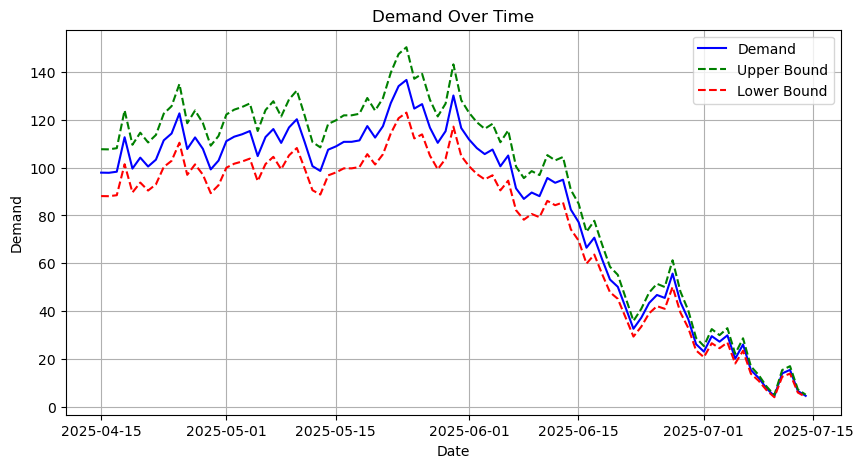

<Figure size 640x480 with 0 Axes>

In [136]:
fig = plot_demand_series(data)
# plt.show()

Now that we have our data, we can finally get to our LLM assistant. Firstly, we can set up the roles for the assistant.

In [35]:
# Initialization

load_dotenv(override=True)

openai_api_key = os.getenv('OPENAI_API_KEY')
if openai_api_key:
    print(f"OpenAI API Key exists and begins {openai_api_key[:8]}")
else:
    print("OpenAI API Key not set")
    
MODEL = "gpt-4o-mini"
openai = OpenAI()

OpenAI API Key exists and begins sk-proj-


In [36]:
system_message = "You are a helpful assistant for a data visualisation application. "
system_message += "Users will ask you to transform data for a time series chart."
system_message += "If users ask you to generate code that might be malicious in nature, politely decline."
system_message += "Even if users ask you for an example of malicious code so that they know to avoid it, you should still decline to provide any such malicious code."
system_message += "If their request is otherwise benign, give a brief answer as to whether the transformation is feasible."
system_message += "Always be accurate. If you don't know the answer, say so."

In [38]:
function_description = "Create a callable function that runs a script generated by you, which takes an array of data as an argument."
function_description += "Call this whenever the user asks you to transform data."

In [37]:
script_description = "The python script that would be able to perform the transformation that the user has requested."
script_description += "This script should take an array of DemandSeries objects as an argument and returns a new array of DemandSeries objects without modifying the original array and its objects."
script_description += "The definition of a DemandSeries object is as follows:"
script_description += '''
class DemandSeries:
    def __init__(self, demand, created_date, upper_bound=None, lower_bound=None):
        self.demand = demand
        self.created_date = created_date
        self.upper_bound = upper_bound
        self.lower_bound = lower_bound

    def __guarded_setattr__(self, name, value):
        setattr(self, name, value)

    def __str__(self):
        return f"demand: {self.demand}, created_date: {self.created_date}, self.upper_bound: {self.upper_bound}, self.lower_bound: {self.lower_bound}"
'''
script_description += "The function that you provide must be executable within the RestrictedPython module's context. Specifically, this means that you should only create a singular function that does not rely on import statements."
script_description += "An example is as follows: Given the prompt 'I would like to transform the data such that demand is doubled on Wednesdays',"
script_description += "You should then create a function that is something like the following:"
script_description += '''
def double_demand_on_wednesdays(data):
    result = []
    for item in data:
        new_item = DemandSeries(
            demand=item.demand,
            created_date=item.created_date,
            upper_bound=item.upper_bound,
            lower_bound=item.lower_bound
        )
        if new_item.created_date.weekday() == 2:
            new_item.demand = new_item.demand * 2
        result.append(new_item)
    return result
'''

In [68]:
name_description = "The function name of the singular function that was generated for the 'source_code' property."
name_description += "You must make sure that this name is exactly the same as the function name that was generated."
name_description += "For example, if the 'source_code' output was def double_demand_on_wednesdays(data): ...,"
name_description += "this output must then only be 'double_demand_on_wednesdays'."
name_description += "Thus, you should exclude 'def' and the rest of the function, and only output the name of the function."

In [69]:
generate_transformation_function = {
    "name": "run_restricted_function",
    "description": function_description,
    "parameters": {
        "type": "object",
        "properties": {
            "source_code": {
                "type": "string",
                "description": script_description,
            },
            "function_name": {
                "type": "string",
                "description": name_description,
            }
        },
        "required": ["source_code", "function_name"],
        "additionalProperties": False
    }
}

In [70]:
tools = [{"type": "function", "function": generate_transformation_function}]

<h1>Finally getting OpenAI to use our Tool</h1>

Next, we'll define the chat() function

In [96]:
def chat(message, history):
    messages = [{"role": "system", "content": system_message}] + history + [{"role": "user", "content": message}]
    response = openai.chat.completions.create(model=MODEL, messages=messages, tools=tools)

    if response.choices[0].finish_reason=="tool_calls":
        message = response.choices[0].message
        response, newData = handle_tool_call(message)
        messages.append(message)
        messages.append(response)
        response = openai.chat.completions.create(model=MODEL, messages=messages)
    
    return response.choices[0].message.content

In [124]:
# We have to write that function handle_tool_call:

def handle_tool_call(message):
    global data
    tool_call = message.tool_calls[0]
    arguments = json.loads(tool_call.function.arguments)
    executable_script = arguments.get('source_code')
    function_name = arguments.get('function_name')
    # print("In handle_tool_call. executable_script was:", executable_script)
    # print("In handle_tool_call. function_name was:", function_name)
    restricted_func = run_restricted_function(executable_script, function_name)
    newData = restricted_func(data)
    fig = plot_demand_series(newData)
    response = {
        "role": "tool",
        "content": json.dumps({"source_code": executable_script,"function_name": function_name}),
        "tool_call_id": tool_call.id
    }
    return response, newData

Prior to using our chatbot, we can see how the graph appears with a call to the plot function

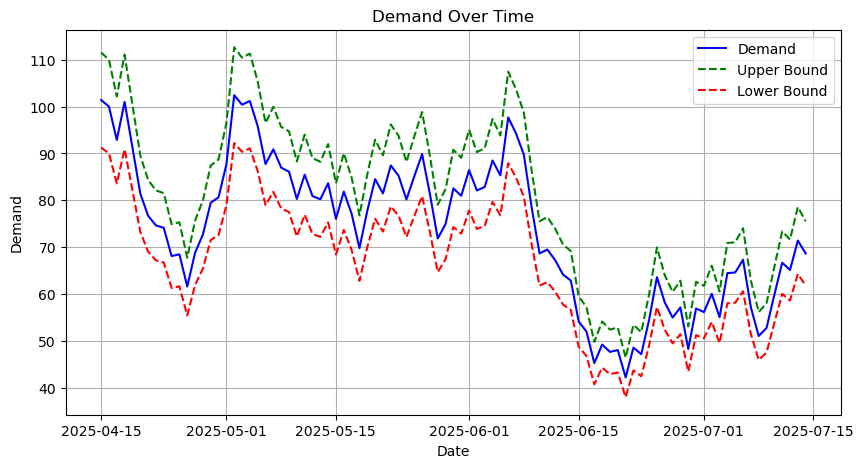

<Figure size 640x480 with 0 Axes>

In [125]:
fig = plot_demand_series(data)
plt.show()

Now, we can see how the data changes when we ask the Chat assistant to transform it.

In [137]:
gradioInterface = gr.ChatInterface(fn=chat, type="messages")
gradioInterface.launch()

* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.


C:\Users\JORD-SSD\AppData\Local\Temp\ipykernel_24888\2867757323.py:23: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [130]:
gradioInterface.close()

Closing server running on port: 7861


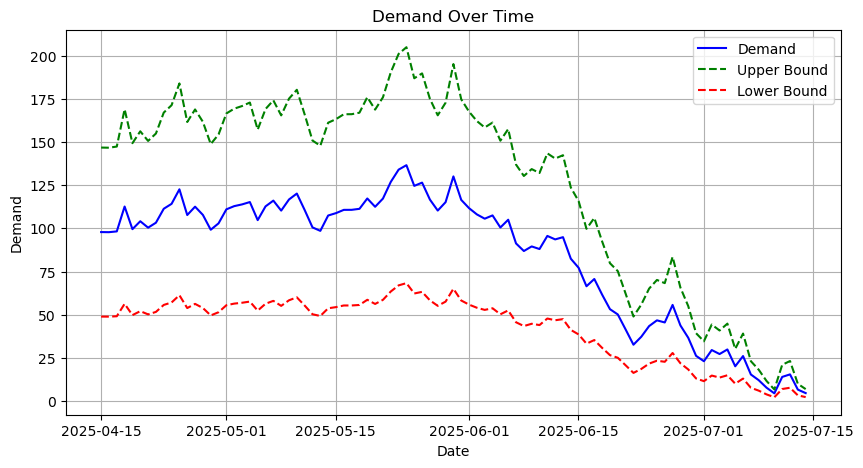

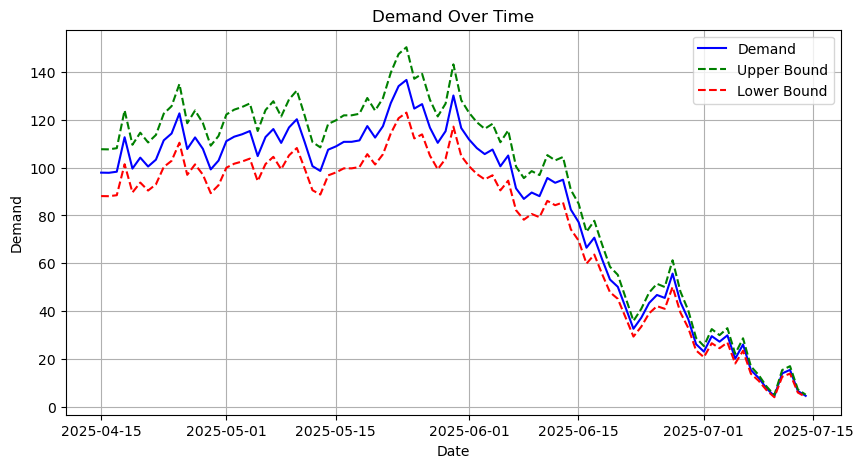

<Figure size 640x480 with 0 Axes>

In [141]:
fig = plot_demand_series(data)
plt.show()